In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureRavdess.csv')

In [ ]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [4]:
df = data
df.shape

(1440, 196)

In [5]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [6]:
data.iloc[:,-3] == 0

0       False
1       False
2       False
3       False
4       False
        ...  
1435     True
1436     True
1437     True
1438     True
1439     True
Name: 0.1, Length: 1440, dtype: bool

In [7]:
X_speaker = df.iloc[:, -1].copy()
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [8]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,14.502933,15.547618,17.645388,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,15.213718,15.513745,17.582760,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,14.972030,15.697508,17.437520,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,15.242136,15.597314,16.492804,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,14.636722,16.023571,17.020093,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,16.391113,18.151034,17.573820,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,16.270073,17.091367,17.932740,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,16.128660,16.947312,18.503842,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,16.307834,17.859030,17.360766,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220


In [9]:
y

0       1
1       1
2       1
3       1
4       2
       ..
1435    8
1436    8
1437    8
1438    8
1439    8
Name: 0.2, Length: 1440, dtype: int64

In [10]:
X_speaker

0        1
1        1
2        1
3        1
4        1
        ..
1435    24
1436    24
1437    24
1438    24
1439    24
Name: speaker, Length: 1440, dtype: int64

In [11]:
X.shape, y.shape

((1440, 193), (1440,))

In [12]:
from sklearn.utils import shuffle

X, y, X_speaker = shuffle(X, y, X_speaker, random_state=42)

In [13]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
168,-521.547302,77.956268,-19.427402,24.423990,-2.413774,-4.131415,-20.575113,-0.134967,-10.341573,0.376268,...,15.013307,16.916615,16.888602,30.432152,-0.020072,0.002151,-0.054975,-0.020576,-0.007031,-0.012101
605,-694.125427,89.352890,17.187904,34.136402,11.057952,19.835867,-1.449472,7.352085,-7.952507,7.914078,...,14.848684,16.186144,15.988606,32.257648,-0.025636,-0.007304,0.002849,-0.087648,0.018231,0.016679
548,-540.653687,64.695663,-12.093176,13.139149,-0.056961,-3.632231,-17.010035,-13.802145,-10.112307,1.112248,...,18.009618,18.633791,19.189384,29.731008,0.008775,0.009064,-0.000060,0.042931,-0.006792,0.007978
65,-635.038208,59.242809,-14.267573,14.177912,-10.723826,0.717458,-9.246791,-6.918327,-6.739667,-1.037649,...,16.948005,18.004542,16.561840,30.620014,-0.106044,0.033797,-0.075319,-0.052065,0.010273,0.003332
628,-518.686218,60.419811,1.542669,15.409612,-3.760008,4.728145,-3.595308,3.629540,-10.236009,0.922400,...,15.830307,17.281869,16.867927,31.741905,-0.019200,0.034101,0.003850,-0.049982,-0.031635,-0.005829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,-619.984009,82.548264,-5.020515,23.687586,-7.415154,18.679161,-6.487446,-1.330336,-13.255409,3.743963,...,16.487207,17.587963,16.703692,31.808119,-0.000666,0.018995,-0.058539,0.018714,0.008222,-0.014984
1130,-409.385651,14.292880,-12.104706,9.623018,-33.162331,6.402128,-18.303886,-10.767341,-13.102248,-0.215422,...,18.456016,20.213013,18.576479,32.108141,-0.050081,-0.015172,0.003873,-0.038299,0.002588,-0.012119
1294,-413.710876,31.911446,-22.527260,2.865191,-12.242773,-9.204301,-14.855512,-9.888793,-23.490492,0.589525,...,18.166894,19.467459,19.658358,33.049526,-0.064942,0.005416,0.000700,-0.013876,0.025157,-0.012493
860,-593.926514,80.987335,-7.736116,21.117559,8.416611,-0.715257,-1.642369,1.938591,-7.679686,4.232740,...,15.803106,16.175938,18.370403,30.476102,-0.011916,0.039719,-0.040311,-0.064398,0.032557,0.013286


In [14]:
X_speaker

168      3
605     11
548     10
65       2
628     11
        ..
1095    19
1130    19
1294    22
860     15
1126    19
Name: speaker, Length: 1440, dtype: int64

In [15]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [16]:
y1

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(1440, 8))

In [17]:
X.shape, y1.shape

((1440, 193), (1440, 8))

In [18]:
X2_speaker = X_speaker.copy().to_numpy()
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [19]:
X2.shape, X2_speaker.shape, y2.shape

((1440, 193), (1440,), (1440,))

In [20]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    #model.add(Conv1D(128, 5,padding='same',))
    #model.add(Activation('relu'))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(8))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    #model.summary()
    return model

In [21]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [22]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-521.547302,77.956268,-19.427402,24.423990,-2.413774,-4.131415,-20.575113,-0.134967,-10.341573,0.376268,...,15.013307,16.916615,16.888602,30.432152,-0.020072,0.002151,-0.054975,-0.020576,-0.007031,-0.012101
1,-694.125427,89.352890,17.187904,34.136402,11.057952,19.835867,-1.449472,7.352085,-7.952507,7.914078,...,14.848684,16.186144,15.988606,32.257648,-0.025636,-0.007304,0.002849,-0.087648,0.018231,0.016679
2,-540.653687,64.695663,-12.093176,13.139149,-0.056961,-3.632231,-17.010035,-13.802145,-10.112307,1.112248,...,18.009618,18.633791,19.189384,29.731008,0.008775,0.009064,-0.000060,0.042931,-0.006792,0.007978
3,-635.038208,59.242809,-14.267573,14.177912,-10.723826,0.717458,-9.246791,-6.918327,-6.739667,-1.037649,...,16.948005,18.004542,16.561840,30.620014,-0.106044,0.033797,-0.075319,-0.052065,0.010273,0.003332
4,-518.686218,60.419811,1.542669,15.409612,-3.760008,4.728145,-3.595308,3.629540,-10.236009,0.922400,...,15.830307,17.281869,16.867927,31.741905,-0.019200,0.034101,0.003850,-0.049982,-0.031635,-0.005829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-619.984009,82.548264,-5.020515,23.687586,-7.415154,18.679161,-6.487446,-1.330336,-13.255409,3.743963,...,16.487207,17.587963,16.703692,31.808119,-0.000666,0.018995,-0.058539,0.018714,0.008222,-0.014984
1436,-409.385651,14.292880,-12.104706,9.623018,-33.162331,6.402128,-18.303886,-10.767341,-13.102248,-0.215422,...,18.456016,20.213013,18.576479,32.108141,-0.050081,-0.015172,0.003873,-0.038299,0.002588,-0.012119
1437,-413.710876,31.911446,-22.527260,2.865191,-12.242773,-9.204301,-14.855512,-9.888793,-23.490492,0.589525,...,18.166894,19.467459,19.658358,33.049526,-0.064942,0.005416,0.000700,-0.013876,0.025157,-0.012493
1438,-593.926514,80.987335,-7.736116,21.117559,8.416611,-0.715257,-1.642369,1.938591,-7.679686,4.232740,...,15.803106,16.175938,18.370403,30.476102,-0.011916,0.039719,-0.040311,-0.064398,0.032557,0.013286


In [23]:
X3_speaker = pd.DataFrame(X2_speaker)
X3_speaker

,0
0,3
1,11
2,10
3,2
4,11
...,...
1435,19
1436,19
1437,22
1438,15


In [24]:
speakers = X_speaker.unique()
speakers

array([ 3, 11, 10,  2, 17, 24, 20,  5, 21, 16, 22, 12, 13,  6, 18, 14,  7,
        1, 15, 19,  9,  8, 23,  4])

In [25]:
X3_col = X3_speaker.rename(columns={0: 'speaker'})
X3_col

,speaker
0,3
1,11
2,10
3,2
4,11
...,...
1435,19
1436,19
1437,22
1438,15


In [26]:
X_combined = pd.concat([X3, X3_col], axis=1)
X_combined

,0,1,2,3,4,5,6,7,8,9,...,184,185,186,187,188,189,190,191,192,speaker
0,-521.547302,77.956268,-19.427402,24.423990,-2.413774,-4.131415,-20.575113,-0.134967,-10.341573,0.376268,...,16.916615,16.888602,30.432152,-0.020072,0.002151,-0.054975,-0.020576,-0.007031,-0.012101,3
1,-694.125427,89.352890,17.187904,34.136402,11.057952,19.835867,-1.449472,7.352085,-7.952507,7.914078,...,16.186144,15.988606,32.257648,-0.025636,-0.007304,0.002849,-0.087648,0.018231,0.016679,11
2,-540.653687,64.695663,-12.093176,13.139149,-0.056961,-3.632231,-17.010035,-13.802145,-10.112307,1.112248,...,18.633791,19.189384,29.731008,0.008775,0.009064,-0.000060,0.042931,-0.006792,0.007978,10
3,-635.038208,59.242809,-14.267573,14.177912,-10.723826,0.717458,-9.246791,-6.918327,-6.739667,-1.037649,...,18.004542,16.561840,30.620014,-0.106044,0.033797,-0.075319,-0.052065,0.010273,0.003332,2
4,-518.686218,60.419811,1.542669,15.409612,-3.760008,4.728145,-3.595308,3.629540,-10.236009,0.922400,...,17.281869,16.867927,31.741905,-0.019200,0.034101,0.003850,-0.049982,-0.031635,-0.005829,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-619.984009,82.548264,-5.020515,23.687586,-7.415154,18.679161,-6.487446,-1.330336,-13.255409,3.743963,...,17.587963,16.703692,31.808119,-0.000666,0.018995,-0.058539,0.018714,0.008222,-0.014984,19
1436,-409.385651,14.292880,-12.104706,9.623018,-33.162331,6.402128,-18.303886,-10.767341,-13.102248,-0.215422,...,20.213013,18.576479,32.108141,-0.050081,-0.015172,0.003873,-0.038299,0.002588,-0.012119,19
1437,-413.710876,31.911446,-22.527260,2.865191,-12.242773,-9.204301,-14.855512,-9.888793,-23.490492,0.589525,...,19.467459,19.658358,33.049526,-0.064942,0.005416,0.000700,-0.013876,0.025157,-0.012493,22
1438,-593.926514,80.987335,-7.736116,21.117559,8.416611,-0.715257,-1.642369,1.938591,-7.679686,4.232740,...,16.175938,18.370403,30.476102,-0.011916,0.039719,-0.040311,-0.064398,0.032557,0.013286,15


In [27]:
# Get random 5 speakers

speaker_counts = X_combined['speaker'].value_counts()
total_speakers = speaker_counts.head(12).index.to_numpy()
selected_speakers = np.random.choice(total_speakers, size=5, replace=False)

print("Selected speakers:", selected_speakers)

Selected speakers: [10 17 11  3 21]


In [28]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=1440
num_fea=125
a=create_index(kfold,totalsize)

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='ravdess_speaker_both_193'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_scaled, axis=2)
    x_testcnn = np.expand_dims(X_test_scaled, axis=2)

    m1= model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {i} Test Accuracy: {score_eval[1]:.4f}")

    # Save data for reproducibility
    np.save(os.path.join(savedir, f"X_train_fold{i}.npy"), x_traincnn)
    np.save(os.path.join(savedir, f"y_train_fold{i}.npy"), y_train)

    np.save(os.path.join(savedir, f"X_test_fold{i}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{i}.npy"), y_test)

    # Save model
    model_name = f"Model_{i}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{i}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)


print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")


===== Fold 0 =====
Test speaker: 10
Train speakers: [ 1  2  3  4  5  6  7  8  9 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
No overlap in fold 0.


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1762260096.084591 2291844 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.2043 - loss: 2.0824 - val_accuracy: 0.1500 - val_loss: 2.0867
Epoch 2/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.3152 - loss: 1.7781 - val_accuracy: 0.1333 - val_loss: 2.1301
Epoch 3/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.3710 - loss: 1.6816 - val_accuracy: 0.1333 - val_loss: 2.1630
Epoch 4/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.4080 - loss: 1.5953 - val_accuracy: 0.1667 - val_loss: 2.1972
Epoch 5/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.4688 - loss: 1.5096 - val_accuracy: 0.2167 - val_loss: 2.2463
Epoch 6/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.5051 - loss: 1.4463 - val_accuracy: 0.2333 - val_loss: 2.2281
Epoch 7/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5261 - loss: 1.4155 - val_accuracy: 0.2500 - val_loss: 2.2636
Epoch 8/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.5493 - loss: 1.3442 - val_accuracy: 0.

Fold 0 Test Accuracy: 0.3500

===== Fold 1 =====
Test speaker: 17
Train speakers: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 20 21 22 23 24]
No overlap in fold 1.


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2159 - loss: 2.0898 - val_accuracy: 0.1500 - val_loss: 2.0923
Epoch 2/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3058 - loss: 1.8147 - val_accuracy: 0.1333 - val_loss: 2.1535
Epoch 3/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3457 - loss: 1.7037 - val_accuracy: 0.1333 - val_loss: 2.1985
Epoch 4/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4058 - loss: 1.6304 - val_accuracy: 0.1333 - val_loss: 2.2218
Epoch 5/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4551 - loss: 1.5512 - val_accuracy: 0.1333 - val_loss: 2.2301
Epoch 6/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4790 - loss: 1.5047 - val_accuracy: 0.1500 - val_loss: 2.2171
Epoch 7/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5138 - loss: 1.4305 - val_accuracy: 0.1667 - val_loss: 2.2081
Epoch 8/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5391 - loss: 1.3791 - val_accuracy: 0.2500 - val_l

Fold 3 Test Accuracy: 0.3333

===== Fold 4 =====
Test speaker: 21
Train speakers: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 22 23 24]
No overlap in fold 4.
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2210 - loss: 2.0920 - val_accuracy: 0.1333 - val_loss: 2.0765
Epoch 2/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3341 - loss: 1.7777 - val_accuracy: 0.1333 - val_loss: 2.1201
Epoch 3/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3667 - loss: 1.6482 - val_accuracy: 0.1667 - val_loss: 2.1945
Epoch 4/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4283 - loss: 1.5878 - val_accuracy: 0.1833 - val_loss: 2.2072
Epoch 5/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4507 - loss: 1.5177 - val_accuracy: 0.2333 - val_loss: 2.1902
Epoch 6/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4993 - loss: 1.4542 - val_accuracy: 0.2667 - val_loss: 2.1764
Epoch 7/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5239 - loss: 1.3987 - val_accuracy: 0.2667 - val_loss: 2.1622
Epoch 8/700
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5572 - loss: 1.3587 - val_accuracy: 0.2167 - val_l

Fold 4 Test Accuracy: 0.3667

===== Cross-validation results =====
Fold 0: Loss=1.8018, Accuracy=0.3500
Fold 1: Loss=1.6944, Accuracy=0.3333
Fold 2: Loss=1.5922, Accuracy=0.3667
Fold 3: Loss=1.6982, Accuracy=0.3333
Fold 4: Loss=1.6842, Accuracy=0.3667

Average accuracy: 0.3500


In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix

savedir = 'ravdess_speaker_both_193'
num_folds = 5 
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

for i in range(num_folds):
    model_name = f"Model_{i}"

    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")

    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    print(f"Fold {i}: Accuracy = {acc:.2f}%")

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)
mean_acc = np.mean(accuracies)

print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))

n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")

2025-11-10 18:11:33.036973: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 18:11:33.069943: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 18:11:33.764577: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-

Fold 0: Accuracy = 35.00%
Fold 1: Accuracy = 33.33%
Fold 2: Accuracy = 36.67%
Fold 3: Accuracy = 33.33%
Fold 4: Accuracy = 36.67%

Mean Accuracy: 35.00%
SD Accuracy: 1.49
95% CI: [33.69%, 36.31%]


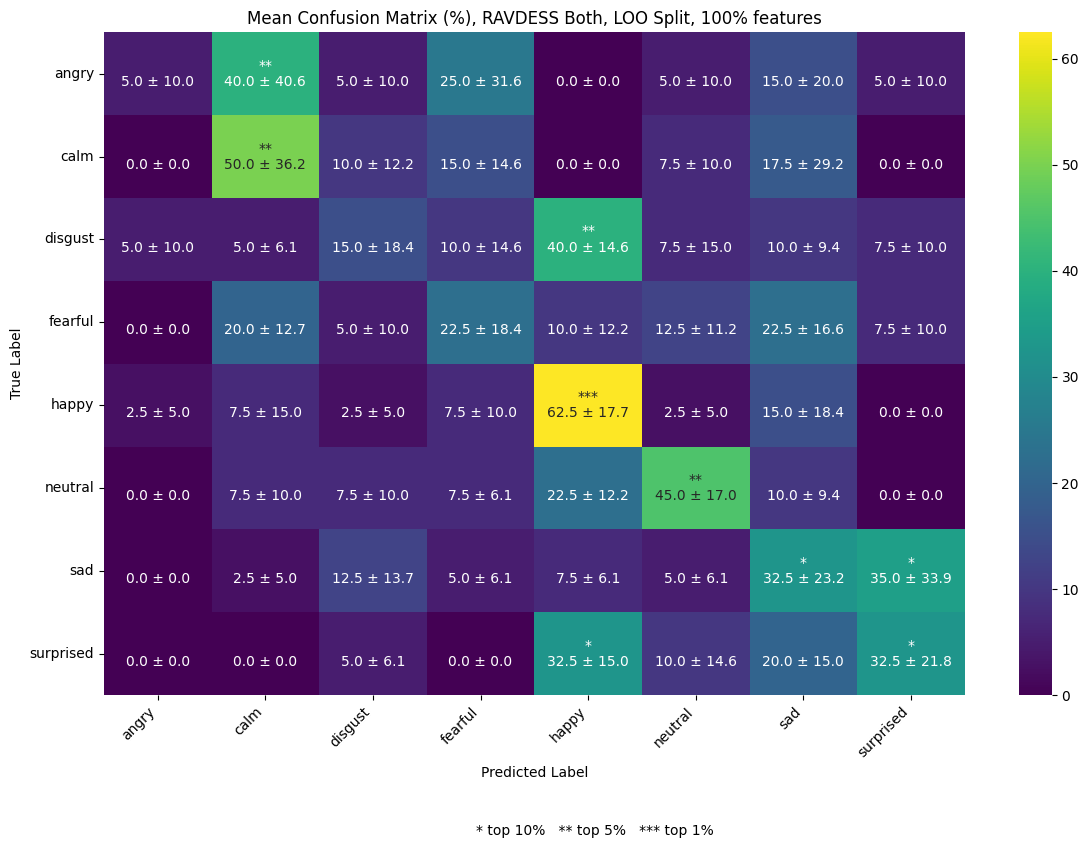

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

np.save('cm_ravdess_speaker_both_193.npy', conf_matrices_percent)


mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}"

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

# Plot
plt.figure(figsize=(12,8))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)

ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(listik, rotation=0)

plt.title("Mean Confusion Matrix (%), RAVDESS Both, LOO Split, 100% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%",
            ha="center", fontsize=10)
plt.show()
